In [1]:
import numpy as np
import matplotlib.pyplot as plt


In [2]:
# ====================================
# MODULE :1 MSE LOSS
# ====================================

def MSE_loss(y,y_pred):
    #Mean squared error 
    mse=np.mean((y-y_pred)**2)
    return mse
    

In [3]:
# ============================================
# MODULE : 2 GRADIENT DECENT (USING CALCULUS)
# ============================================

def MSE_gradient_decent(y,X,w,b):
    #Number of training data
    n=len(y)
    
    #predicted y
    y_pred= w*X+b
    
    #Rate of chnage of W when b is constant i.e partial derivative
    dw = -(2/n)*np.sum(X*(y-y_pred))
    
    #Rate of chnage of b when w is constant i.e. partial derivative
    db=-(2/n)*np.sum(y-y_pred)
    
    return dw,db 
    


In [4]:
# ============================================
# MODULE : 3 NUMERICAL GRADIENT
# ============================================


def numerical_gradient(y,X,w,b,esp=1e-7):
   
    #Rate of change of w when b is consant
    loss_plus_w = MSE_loss(y,(w+esp)*X+b)
    loss_mins_w = MSE_loss(y,(w-esp)*X+b)
    dw_n=(loss_plus_w - loss_mins_w)/(2*esp)
    
    #Rate of change of b when w is consant
    loss_plus_b = MSE_loss(y,w*X + (b+esp))
    loss_mins_b = MSE_loss(y,w*X+(b-esp))
    db_n=(loss_plus_b - loss_mins_b)/(2*esp)
    
    return dw_n,db_n

    


In [5]:
# ============================================
# MODULE : 4 SYNTHETICALY GENERATED DATA 
# ============================================

#True w and b 
w,b=2,1

#single feature values
np.random.seed(56)
X = np.linspace(0,10,20)

#Adding noise in X
noise=np.random.normal(0,0.5,size=len(X))

#Actual vlaues of y 
y= w*X + b +noise 


In [6]:
# ============================================
# MODULE : 5 TEST CASES 
# ============================================

#initialise with different weight(w) and intercept(b)
w_test,b_test = 1.5,1

#using calculus
dw_analytical,db_analytical=MSE_gradient_decent(y,X,w_test,b_test)

#Using Numerical nudge
dw_numerical,db_numerical = numerical_gradient(y,X,w_test,b_test)


print(f"Analytical dw: {dw_analytical:.6f}")
print(f"Numerical dw:  {dw_numerical:.6f}")
print(f"Difference:    {abs(dw_analytical - dw_numerical):.2e}")



Analytical dw: -35.324490
Numerical dw:  -35.324490
Difference:    6.60e-09


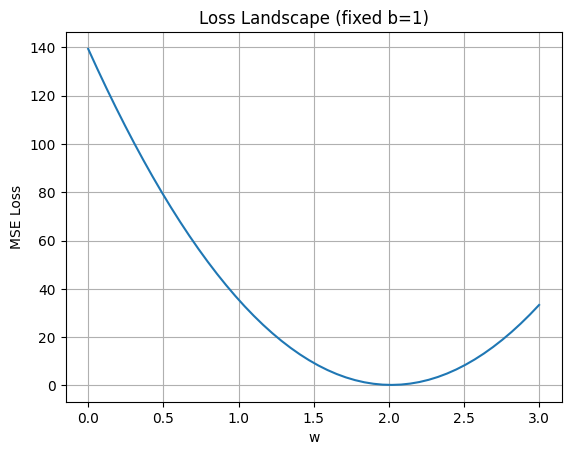

In [7]:
w_vals = np.linspace(0, 3, 50)
losses = [MSE_loss(y, w*X + 1.0) for w in w_vals]  # fix b=1

plt.plot(w_vals, losses)
plt.xlabel('w')
plt.ylabel('MSE Loss')
plt.title('Loss Landscape (fixed b=1)')
plt.grid(True)
plt.show()
